<a href="https://colab.research.google.com/github/marcusslongweek/Homework/blob/main/CS4410HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5

## 1. K-Means on the Iris dataset


In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

wcss


[681.3705999999996,
 152.34795176035797,
 78.851441426146,
 57.22847321428572,
 46.44618205128204,
 39.03998724608725,
 34.42019178628389,
 30.064593073593088,
 28.332569264069274,
 25.972596377306918]

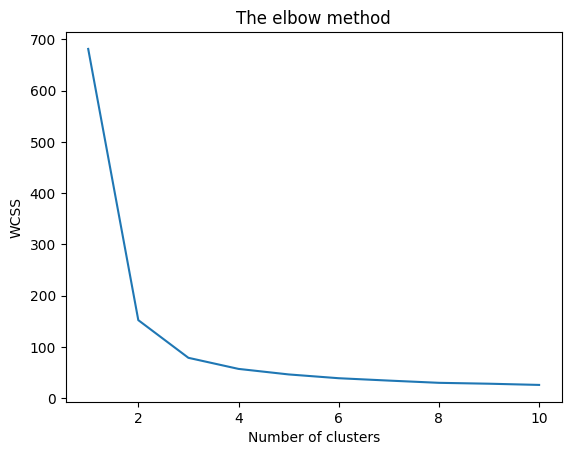

In [2]:
plt.plot(range(1, 11), wcss)
plt.title("The elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


The elbow looks like it is around **3 clusters**, so I would use `k = 3` for the Iris dataset.


## 2. Logistic Regression on MNIST with and without PCA


In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time


In [4]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

X_train.shape, X_test.shape


((56000, 784), (14000, 784))

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Without PCA


In [6]:
logisticRegr = LogisticRegression(solver='lbfgs', max_iter=1000)

start = time.time()
logisticRegr.fit(X_train, y_train)
end = time.time()

predictions = logisticRegr.predict(X_test)

time_without_pca = end - start
accuracy_without_pca = accuracy_score(y_test, predictions)

print("Time without PCA:", time_without_pca)
print("Accuracy without PCA:", accuracy_without_pca)


Time without PCA: 65.3272352218628
Accuracy without PCA: 0.9097857142857143


### With PCA


In [7]:
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("Features after PCA:", X_train_pca.shape[1])


Original features: 784
Features after PCA: 327


In [8]:
logisticRegrPCA = LogisticRegression(solver='lbfgs', max_iter=1000)

start = time.time()
logisticRegrPCA.fit(X_train_pca, y_train)
end = time.time()

predictions_pca = logisticRegrPCA.predict(X_test_pca)

time_with_pca = end - start
accuracy_with_pca = accuracy_score(y_test, predictions_pca)

print("Time with PCA:", time_with_pca)
print("Accuracy with PCA:", accuracy_with_pca)


Time with PCA: 55.341529846191406
Accuracy with PCA: 0.9182142857142858


In [9]:
print("Without PCA:")
print("Time:", time_without_pca)
print("Accuracy:", accuracy_without_pca)

print()

print("With PCA:")
print("Time:", time_with_pca)
print("Accuracy:", accuracy_with_pca)


Without PCA:
Time: 65.3272352218628
Accuracy: 0.9097857142857143

With PCA:
Time: 55.341529846191406
Accuracy: 0.9182142857142858


PCA reduced the number of features before logistic regression. After running both models, the times and accuracy scores above can be compared to see how much PCA helped.
